### Normalization is a technique used to change the values of numeric values in the columns to use a common scale

# Min-Max Scaling

#### The scale for this distribution will always be [0,1]
#### The formula is (xi-xmin)/(xmax-xmin)

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('wine_data.csv', header=None, usecols=[0, 1, 2])
df.columns = ['Class label', 'Alcohol', 'Malic acid']
df


,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

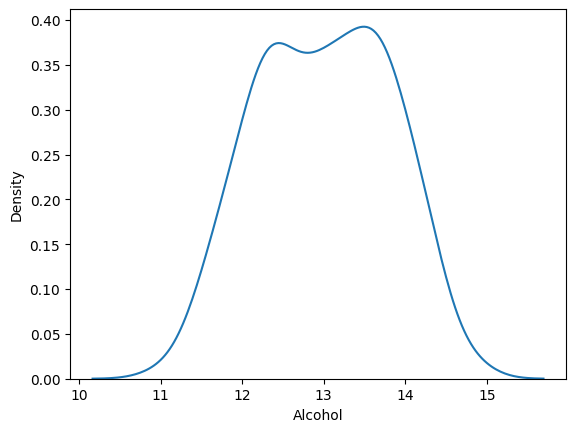

In [9]:
sns.kdeplot(df['Alcohol'])

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df[['Alcohol', 'Malic acid']], df['Class label'], test_size=0.2, random_state=0)

X_train.shape, X_test.shape

((142, 2), (36, 2))

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [18]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,142.0,142.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


# Mean Normalization

#### Take numerical data and normalize it
* xi' = (xi-mean)/(xmax-xmin)
* [-1,1] range

# MaxAbsScaling

* xi' = xi/abs(xmax)
* useful when sparce data (a lot of 0's)

# Robust Scaling

#### xi' = (xi-xmedian)/IQR
* you can use this if there are a lot of outliers
